In [1]:
import geopandas as gpd
import ee
import xee
import numpy as np
import xarray as xr
import os
from glob import glob
import matplotlib.pyplot as plt

In [2]:
scan_id = "2025-12-senegal-dakar"
cityname  = scan_id.split('-')[-1] 

aoi_dir = os.path.join('mnt', scan_id, '01-user-input', 'AOI')
print(aoi_dir)
aoi_file = glob(aoi_dir + "/*.shp")
print(aoi_file)


mnt/2025-12-senegal-dakar/01-user-input/AOI
['mnt/2025-12-senegal-dakar/01-user-input/AOI/dakar-fua.shp', 'mnt/2025-12-senegal-dakar/01-user-input/AOI/South_Jakarta-Jakarta.shp']


In [3]:
import yaml
city_inputs_dir = os.path.join('mnt', scan_id, '01-user-input', 'city_inputs.yml')
city_inputs_dir

with open(city_inputs_dir) as f:
      city_inputs = yaml.safe_load(f)

print(city_inputs['first_year'], city_inputs['last_year'])



city_name = city_inputs['city_name'].replace(' ', '_').replace("'", "").lower()
first_year = city_inputs['first_year']
last_year = city_inputs['last_year']

output_dir = "temp"

2015 2024


In [4]:
aoi = gpd.read_file(aoi_file[0]).to_crs(4326)
aoi

,eFUA_ID,UC_num,UC_IDs,eFUA_name,Commuting,Cntry_ISO,Cntry_name,FUA_area,UC_area,FUA_p_2015,UC_p_2015,Com_p_2015,geometry
0,153.0,1.0,1452,Dakar,1.0,SEN,Senegal,388.0,277.0,3.409806e+06,3.358310e+06,51496.882791,"POLYGON ((-17.27968 14.8235, -17.26949 14.8235..."


In [5]:
from utils.aoi_module import find_country
country_iso3, country_name = find_country(aoi)
country_iso3

/Users/vivaldirinaldi/Documents/Work/city-scan-automation/utils/aoi_module.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection['area'] = intersection.geometry.area
2026-02-26 21:07:12,226 | INFO | utils.aoi_module | aoi_module.py:31 | detect ISO3 from AOI: sen


'sen'

In [6]:
from tasks.population_worldpop import datacollection as wp_collect

In [7]:
pop_array, pop_meta = wp_collect.datacollection(aoi=aoi, city_name=city_name, country_iso3=country_iso3, output_dir=output_dir, return_raster=True)

2026-02-26 21:07:12,422 | INFO | tasks.population_worldpop.datacollection | datacollection.py:112 | Starting WorldPop data collection…
2026-02-26 21:07:12,422 | INFO | tasks.population_worldpop.datacollection | datacollection.py:112 | Starting WorldPop data collection…
2026-02-26 21:07:12,424 | INFO | tasks.population_worldpop.datacollection | datacollection.py:123 | AOI CRS: EPSG:4326
2026-02-26 21:07:12,424 | INFO | tasks.population_worldpop.datacollection | datacollection.py:123 | AOI CRS: EPSG:4326
2026-02-26 21:07:12,426 | INFO | tasks.population_worldpop.datacollection | datacollection.py:142 | Requesting WorldPop raster: https://storage.googleapis.com/city-scan-global-public/world_population/sen_ppp_2020_constrained.tif
2026-02-26 21:07:12,426 | INFO | tasks.population_worldpop.datacollection | datacollection.py:142 | Requesting WorldPop raster: https://storage.googleapis.com/city-scan-global-public/world_population/sen_ppp_2020_constrained.tif
2026-02-26 21:07:13,404 | INFO | t

2026-02-26 21:08:03,880 | INFO | tasks.population_worldpop.datacollection | datacollection.py:197 | WorldPop Global 1 saved to: temp/spatial/dakar_worldpop_2000_2020.tif (21 bands)
2026-02-26 21:08:03,880 | INFO | tasks.population_worldpop.datacollection | datacollection.py:197 | WorldPop Global 1 saved to: temp/spatial/dakar_worldpop_2000_2020.tif (21 bands)
2026-02-26 21:08:03,881 | INFO | tasks.population_worldpop.datacollection | datacollection.py:203 | Starting WorldPop Global 2 data collection (2015-2030)...
2026-02-26 21:08:03,881 | INFO | tasks.population_worldpop.datacollection | datacollection.py:203 | Starting WorldPop Global 2 data collection (2015-2030)...


2026-02-26 21:08:23,051 | INFO | tasks.population_worldpop.datacollection | datacollection.py:233 | WorldPop Global 2 saved to: temp/spatial/dakar_worldpop_2015_2030.tif (16 bands)
2026-02-26 21:08:23,051 | INFO | tasks.population_worldpop.datacollection | datacollection.py:233 | WorldPop Global 2 saved to: temp/spatial/dakar_worldpop_2015_2030.tif (16 bands)
2026-02-26 21:08:23,053 | INFO | tasks.population_worldpop.datacollection | datacollection.py:235 | WorldPop complete.
2026-02-26 21:08:23,053 | INFO | tasks.population_worldpop.datacollection | datacollection.py:235 | WorldPop complete.


In [8]:
pop_array

{'g1_2020': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 'g1_multiyear': array([[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],
 
        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],
 
        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan

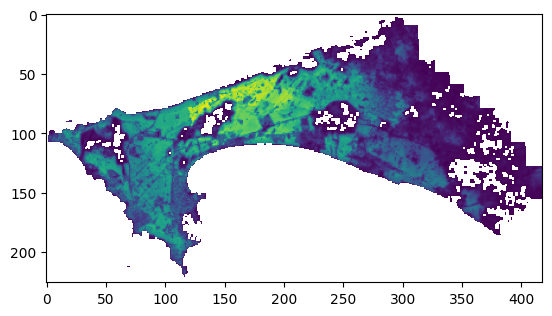

In [9]:
plt.imshow(pop_array['g2'][0], cmap='viridis')

In [10]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.path.expanduser("~/.config/gcloud/application_default_credentials.json")

In [11]:
from tasks.wsf import datacollection as wsf_collect

wsf_arrays, wsf_metas = wsf_collect.datacollection(aoi=aoi, city_name=city_name, output_dir=output_dir, return_raster=True)

2026-02-26 21:08:23,273 | INFO | tasks.wsf.datacollection | datacollection.py:102 | Starting WSF data collection...
2026-02-26 21:08:23,273 | INFO | tasks.wsf.datacollection | datacollection.py:102 | Starting WSF data collection...
2026-02-26 21:08:23,275 | INFO | tasks.wsf.datacollection | datacollection.py:122 | Collecting WSF Tracker...
2026-02-26 21:08:23,275 | INFO | tasks.wsf.datacollection | datacollection.py:122 | Collecting WSF Tracker...
2026-02-26 21:08:25,326 | INFO | tasks.wsf.datacollection | datacollection.py:131 |   Opened tile: WSFtracker_20160701-20250701_-18_14.tif
2026-02-26 21:08:25,326 | INFO | tasks.wsf.datacollection | datacollection.py:131 |   Opened tile: WSFtracker_20160701-20250701_-18_14.tif
2026-02-26 21:08:27,107 | INFO | tasks.wsf.datacollection | datacollection.py:164 | WSF Tracker saved to: temp/spatial/dakar_wsf_tracker.tif
2026-02-26 21:08:27,107 | INFO | tasks.wsf.datacollection | datacollection.py:164 | WSF Tracker saved to: temp/spatial/dakar_wsf_

KeyboardInterrupt: 

In [ ]:
wsf_arrays.keys()

dict_keys(['tracker', 'evolution'])

In [ ]:
np.unique(wsf_arrays['tracker'])

array([   0. , 2016.5, 2017. , 2017.5, 2018. , 2018.5, 2019. , 2019.5,
       2020. , 2020.5, 2021. , 2021.5, 2022. , 2022.5, 2023. , 2023.5,
       2024. , 2024.5, 2025. , 2025.5], dtype=float32)

In [ ]:
from tasks.wsf import dataanalysis as wsf_analysis

harmonized, _ = wsf_analysis.harmonize_wsf(
      city_name=city_name,
      output_dir=output_dir,
      return_df=True
  )

2026-02-23 13:43:56,770 | INFO | tasks.wsf.dataanalysis | dataanalysis.py:188 | Starting WSF harmonization...
2026-02-23 13:43:56,872 | INFO | tasks.wsf.dataanalysis | dataanalysis.py:219 | Applying morphological closing to WSF Tracker...
2026-02-23 13:44:00,543 | INFO | tasks.wsf.dataanalysis | dataanalysis.py:237 | Resampling tracker to evolution resolution...
2026-02-23 13:44:00,562 | INFO | tasks.wsf.dataanalysis | dataanalysis.py:251 | Combining Evolution + Tracker...
2026-02-23 13:44:00,577 | INFO | tasks.wsf.dataanalysis | dataanalysis.py:283 | Harmonized WSF saved to: temp/spatial/dakar_wsf_harmonized.tif
2026-02-23 13:44:00,577 | INFO | tasks.wsf.dataanalysis | dataanalysis.py:289 | Computing harmonized stats...
2026-02-23 13:44:00,611 | INFO | tasks.wsf.dataanalysis | dataanalysis.py:328 | Harmonized WSF stats saved to: temp/tabular/processed/dakar_wsf_harmonized.csv


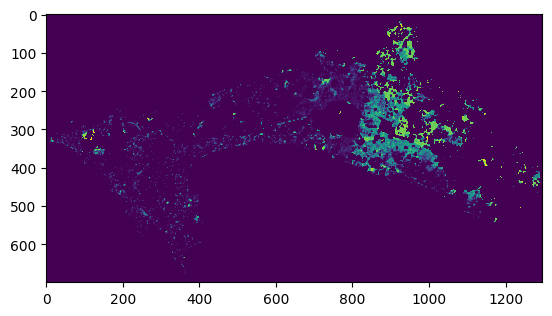

In [ ]:
plt.imshow(harmonized.squeeze(), vmin = 1985, vmax = 2025)

### Overall checklist 

In [ ]:
scan_id = "2026-02-bangladesh-bogura"
cityname  = scan_id.split('-')[-1] 

aoi_dir = os.path.join('mnt', scan_id, '01-user-input', 'AOI')
print(aoi_dir)
aoi_file = glob(aoi_dir + "/*.shp")
print(aoi_file)


In [ ]:
import yaml
source = os.path.join('mnt', scan_id, '01-user-input', 'city_inputs.yml')
city_inputs_dir

with open(city_inputs_dir) as f:
      city_inputs = yaml.safe_load(f)

print(city_inputs['first_year'], city_inputs['last_year'])
